In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## Main Report:

This notebook loads **both** trained models (Forward and Reverse) and evaluates them on a single fresh held-out test set, so the comparison satisfies the task's "same test examples" requirement regardless of what either training notebook used internally.


In [2]:
FORWARD_CKPT_PATH = "2026y09m10d-14h54m10s-ForwardAddSubLM.pkl"
REVERSE_CKPT_PATH = "LLMReverse_best_2.pth"

NINP, NHEAD, NHID, NLAYERS = 128, 16, 64, 6   
NUMBER_DIGITS = 3
TEST_SIZE = 12000                              
REPORT_SEED = 2024                             

random.seed(REPORT_SEED)
torch.manual_seed(REPORT_SEED)

### Tokeniser (identical to both training notebooks)

In [3]:
pad_token = "[PAD]"
eos_token = "[EOS]"


class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        return re.sub(self.pattern, "", text)

    def encode(self, text):
        return [self.token_to_id[c] for c in self.clean(text)]

    def decode(self, token_list):
        return "".join(self.id_to_token[i] for i in token_list)


tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
EQ_ID = tokenizer.token_to_id["="]
EOS_ID = tokenizer.token_to_id[eos_token]
PAD_ID = tokenizer.token_to_id[pad_token]

### Model architecture (identical to both training notebooks)

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(1e4) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False,
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src


class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        return torch.log(torch.tril(torch.ones(sz, sz)))

    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        output_enc = self.input_emb(src) * math.sqrt(self.ninp)
        output_enc = self.pos_encoder(output_enc)
        output_enc = self.encoder(output_enc, mask=mask)
        output_dec = self.decoder(output_enc)
        return F.log_softmax(output_dec, dim=-1), output_enc, None

### Load both trained models

In [5]:
def load_model(ckpt_path):
    m = TransformerModel(ntoken=ntokens, ninp=NINP, nhead=NHEAD, nhid=NHID, nlayers=NLAYERS).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    m.load_state_dict(state)
    m.eval()
    return m


print("Loading checkpoints...")
model_fwd = load_model(FORWARD_CKPT_PATH)
model_rev = load_model(REVERSE_CKPT_PATH)
print("Both models loaded.")

Loading checkpoints...
Both models loaded.


/tmp/ipykernel_615/418789500.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


### Generation / parsing helpers

Parameterised by `reverse` (not a global flag), so both models' conventions can coexist safely in the same script.

In [6]:
def generate(model, prompts, new_tokens=5):
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        token = torch.argmax(output[-1, :, :], -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor


def parse_target_string(s, reverse):
    if s in ("", "-"):
        return None
    if s.startswith("-"):
        s = "-" + (s[1:][::-1] if reverse else s[1:])
    elif reverse:
        s = s[::-1]
    try:
        return int(s)
    except ValueError:
        return None


def predict_sample(model, prompt, reverse, max_new_tokens=6):
    prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1, 1))
    output_tensor = generate(model, prompt_tensor, max_new_tokens)[:, 0]
    output_list = output_tensor.tolist()
    try:
        pred_tokens = output_list[output_list.index(EQ_ID) + 1:]
        if EOS_ID in pred_tokens:
            pred_tokens = pred_tokens[: pred_tokens.index(EOS_ID)]
        pred_str = tokenizer.decode(pred_tokens)
        return parse_target_string(pred_str, reverse)
    except (ValueError, IndexError):
        return None


def parse_equation(prompt):
    op = "+" if "+" in prompt else "-"
    a_str, b_str = prompt.replace("=", "").split(op)
    return int(a_str), int(b_str), op


def check_carries_or_borrows(a_int, b_int, op, result_int):
    number_digits = len(str(abs(result_int)))
    str_a = str(a_int).zfill(number_digits)
    str_b = str(b_int).zfill(number_digits)
    carry_or_borrow = 0
    used_flags = []
    for i in reversed(range(number_digits)):
        digit_a, digit_b = int(str_a[i]), int(str_b[i])
        used_flags.append(1 if carry_or_borrow == 1 else 0)
        if op == "+":
            carry_or_borrow = 1 if (digit_a + digit_b + carry_or_borrow >= 10) else 0
        else:
            carry_or_borrow = 1 if (digit_a - digit_b - carry_or_borrow < 0) else 0
    used_flags.reverse()
    return used_flags

### Building one fresh, shared held-out test set as we both used seperate hold out test amounts and i used seed. 

Both models will be evaluated on exactly this data.

In [7]:
print(f"Generating a fresh shared test set (seed={REPORT_SEED}, n={TEST_SIZE})...")
raw_test = []
seen = set()
while len(raw_test) < TEST_SIZE:
    a_list = [random.randint(0, 9) for _ in range(NUMBER_DIGITS)]
    b_list = [random.randint(0, 9) for _ in range(NUMBER_DIGITS)]
    a_int = int("".join(str(x) for x in a_list))
    b_int = int("".join(str(x) for x in b_list))
    op = random.choice(["+", "-"])
    triple = (a_int, b_int, op)
    if triple not in seen:
        seen.add(triple)
        raw_test.append(triple)

prompts_test = [f"{str(a).zfill(NUMBER_DIGITS)}{op}{str(b).zfill(NUMBER_DIGITS)}=" for a, b, op in raw_test]
n_add = sum(1 for _, _, op in raw_test if op == "+")
print(f"test set: {len(raw_test)} examples ({n_add} addition, {len(raw_test)-n_add} subtraction)")

Generating a fresh shared test set (seed=2024, n=12000)...
test set: 12000 examples (5994 addition, 6006 subtraction)


### Evaluate both models on the identical prompt list

In [8]:
def full_eval(model, reverse, mode_name):
    rows = []
    for (a_int, b_int, op), prompt in tqdm(list(zip(raw_test, prompts_test)), desc=f"eval-{mode_name}"):
        true_result = a_int + b_int if op == "+" else a_int - b_int
        pred = predict_sample(model, prompt, reverse)
        correct = (pred == true_result)

        true_str = str(abs(true_result)).zfill(4)
        pred_str = str(abs(pred)).zfill(4) if pred is not None else "----"
        digit_correct = [pred_str[i] == true_str[i] for i in range(4)] if pred is not None else [False] * 4
        sign_correct = (pred is not None) and ((pred < 0) == (true_result < 0))
        carries = check_carries_or_borrows(a_int, b_int, op, true_result)

        rows.append({
            "mode": mode_name, "a": a_int, "b": b_int, "op": op,
            "true_result": true_result, "pred_result": pred, "correct": correct,
            "sign_correct": sign_correct,
            "thousands_correct": digit_correct[0], "hundreds_correct": digit_correct[1],
            "tens_correct": digit_correct[2], "units_correct": digit_correct[3],
            "has_carry_or_borrow": sum(carries) > 0,
            "n_carries_or_borrows": sum(carries),
            "operand_length": max(len(str(a_int)), len(str(b_int))),
        })
    return pd.DataFrame(rows)


df_fwd = full_eval(model_fwd, reverse=False, mode_name="forward")
df_rev = full_eval(model_rev, reverse=True, mode_name="reverse")
df_all = pd.concat([df_fwd, df_rev], ignore_index=True)
df_all.to_csv("task3_comparative_results.csv", index=False)
print("saved task3_comparative_results.csv")

digit_cols = ["thousands_correct", "hundreds_correct", "tens_correct", "units_correct"]

eval-reverse: 100%|██████████| 12000/12000 [02:49<00:00, 70.84it/s]


saved task3_comparative_results.csv


### Headline: overall accuracy (target ≥ 0.78)

In [9]:
print("\n=== Overall accuracy (target: >= 0.78) ===")
overall = df_all.groupby("mode")["correct"].mean()
print(overall)
for mode, acc in overall.items():
    print(f"  {mode}: {acc:.2%} [{'PASS' if acc >= 0.78 else 'BELOW TARGET'}]")


=== Overall accuracy (target: >= 0.78) ===
mode
forward    0.976083
reverse    0.898167
Name: correct, dtype: float64
  forward: 97.61% [PASS]
  reverse: 89.82% [PASS]


### Operation robustness

In [10]:
print("\n=== Operation robustness (accuracy by op x mode) ===")
op_summary = df_all.groupby(["mode", "op"])["correct"].mean()
print(op_summary)


=== Operation robustness (accuracy by op x mode) ===
mode     op
forward  +     0.990824
         -     0.961372
reverse  +     0.934268
         -     0.862138
Name: correct, dtype: float64


### Digit-level performance

In [11]:
print("\n=== Digit-position accuracy (mode) ===")
print(df_all.groupby("mode")[digit_cols].mean())

print("\n=== Digit-position accuracy (mode x op) ===")
print(df_all.groupby(["mode", "op"])[digit_cols].mean())


=== Digit-position accuracy (mode) ===
         thousands_correct  hundreds_correct  tens_correct  units_correct
mode                                                                     
forward           1.000000          0.998583      0.991917       0.985000
reverse           0.991833          0.903583      0.994750       0.996083

=== Digit-position accuracy (mode x op) ===
            thousands_correct  hundreds_correct  tens_correct  units_correct
mode    op                                                                  
forward +             1.00000          0.999333      0.996330       0.994995
        -             1.00000          0.997835      0.987512       0.975025
reverse +             0.98365          0.934434      1.000000       1.000000
        -             1.00000          0.872794      0.989510       0.992174


### Direction effects (paired comparison)

In [12]:
paired = df_fwd.merge(df_rev, on=["a", "b", "op"], suffixes=("_fwd", "_rev"))
print("\n=== Direction effect (paired on identical problems) ===")
print(f"forward correct, reverse wrong: {((paired.correct_fwd) & (~paired.correct_rev)).sum()}")
print(f"reverse correct, forward wrong: {((paired.correct_rev) & (~paired.correct_fwd)).sum()}")
print(f"both correct: {((paired.correct_fwd) & (paired.correct_rev)).sum()}")
print(f"both wrong:   {((~paired.correct_fwd) & (~paired.correct_rev)).sum()}")


=== Direction effect (paired on identical problems) ===
forward correct, reverse wrong: 1196
reverse correct, forward wrong: 261
both correct: 10517
both wrong:   26


### Error patterns

In [13]:
print("\n=== Accuracy vs. carry/borrow ===")
print(df_all.groupby(["mode", "has_carry_or_borrow"])["correct"].mean())

print("\n=== Accuracy vs. number of carries/borrows ===")
print(df_all.groupby(["mode", "n_carries_or_borrows"])["correct"].mean())

print("\n=== Accuracy vs. operand length ===")
print(df_all.groupby(["mode", "operand_length"])["correct"].mean())

neg = df_all[df_all["true_result"] < 0]
print("\n=== Sign accuracy on negative-result examples ===")
print(neg.groupby("mode")["sign_correct"].mean())


=== Accuracy vs. carry/borrow ===
mode     has_carry_or_borrow
forward  False                  0.949935
         True                   0.985175
reverse  False                  0.879522
         True                   0.904650
Name: correct, dtype: float64

=== Accuracy vs. number of carries/borrows ===
mode     n_carries_or_borrows
forward  0                       0.949935
         1                       0.981785
         2                       0.988206
         3                       0.993719
reverse  0                       0.879522
         1                       0.894187
         2                       0.906890
         3                       0.959799
Name: correct, dtype: float64

=== Accuracy vs. operand length ===
mode     operand_length
forward  1                 0.000000
         2                 0.813953
         3                 0.977928
reverse  1                 0.000000
         2                 0.891473
         3                 0.898315
Name: correct, dtype:

### Plots


saved task3_comparative_analysis.png


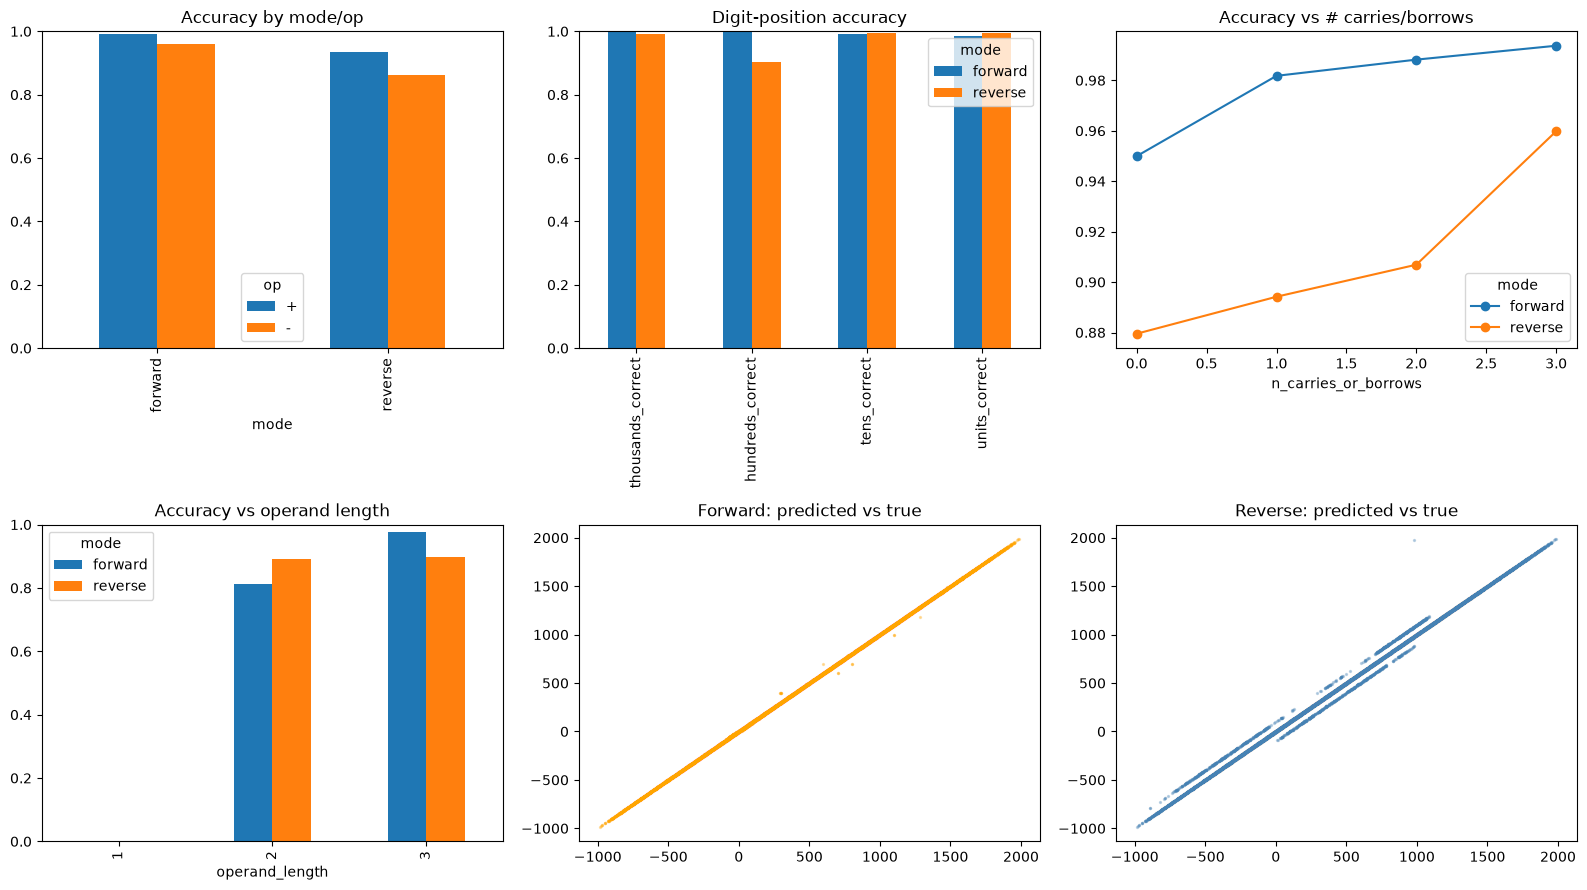

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

op_summary.unstack().plot(kind="bar", ax=axes[0, 0]); axes[0, 0].set_title("Accuracy by mode/op"); axes[0, 0].set_ylim(0, 1)
df_all.groupby("mode")[digit_cols].mean().T.plot(kind="bar", ax=axes[0, 1]); axes[0, 1].set_title("Digit-position accuracy"); axes[0, 1].set_ylim(0, 1)
df_all.groupby(["mode", "n_carries_or_borrows"])["correct"].mean().unstack(0).plot(ax=axes[0, 2], marker="o"); axes[0, 2].set_title("Accuracy vs # carries/borrows")
df_all.groupby(["mode", "operand_length"])["correct"].mean().unstack(0).plot(kind="bar", ax=axes[1, 0]); axes[1, 0].set_title("Accuracy vs operand length"); axes[1, 0].set_ylim(0, 1)

sub_fwd = df_fwd.dropna(subset=["pred_result"])
axes[1, 1].scatter(sub_fwd["true_result"], sub_fwd["pred_result"], s=2, alpha=0.3, c="orange")
axes[1, 1].set_title("Forward: predicted vs true")

sub_rev = df_rev.dropna(subset=["pred_result"])
axes[1, 2].scatter(sub_rev["true_result"], sub_rev["pred_result"], s=2, alpha=0.3, c="steelblue")
axes[1, 2].set_title("Reverse: predicted vs true")

plt.tight_layout()
plt.savefig("task3_comparative_analysis.png", dpi=150)
print("\nsaved task3_comparative_analysis.png")